<a href="https://colab.research.google.com/github/hrudaykrishnareddy03/hello-world/blob/main/EDA_Project_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 1. Importing the dataset using pandas from given url

In [108]:
auto = pd.read_csv('/content/Automobile_data.csv')
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [109]:
auto.tail()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


## 2. High Level Data Understanding:

In [110]:
auto.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [111]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

### 3. Data cleaning

In [112]:
auto.replace('?', np.nan, inplace =True)

In [113]:
auto.duplicated().sum()

np.int64(0)

In [114]:
auto.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


### Type casting coulumns

In [115]:
auto['price'] = auto['price'].apply(float)
auto['peak-rpm'] = auto['peak-rpm'].apply(float)
auto['horsepower'] = auto['horsepower'].apply(float)

In [116]:
print('Fuel Types       : ', auto['fuel-type'].unique())
print('Body Styles      : ', auto['body-style'].unique())
print('Drive Wheels     : ', auto['drive-wheels'].unique())
print('Fuel System      : ', auto['fuel-system'].unique())
print('Engine Type      : ', auto['engine-type'].unique())
print('Aspiration       : ', auto['aspiration'].unique())
print('No. of Cylinders : ', auto['num-of-cylinders'].unique())

Fuel Types       :  ['gas' 'diesel']
Body Styles      :  ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
Drive Wheels     :  ['rwd' 'fwd' '4wd']
Fuel System      :  ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']
Engine Type      :  ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
Aspiration       :  ['std' 'turbo']
No. of Cylinders :  ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']


In [117]:
auto['comb_mpg'] = (auto['city-mpg'] + auto['highway-mpg']) / 2
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,comb_mpg
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,24.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,24.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,22.5
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.4,10.0,102.0,5500.0,24,30,13950.0,27.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.4,8.0,115.0,5500.0,18,22,17450.0,20.0


In [118]:
auto['body-style'].value_counts()

,count
body-style,
sedan,96
hatchback,70
wagon,25
hardtop,8
convertible,6


* Observation: Most selling body-type cars are Sedans.

In [119]:
q1 = auto.price.quantile(0.25)
q2 = auto.price.quantile(0.50)
q3 = auto.price.quantile(0.75)
iqr = q3 - q1
print(q1, q2, q3, iqr, sep = '\n')

7775.0
10295.0
16500.0
8725.0


In [120]:
upper = q3  + 1.5 * iqr
lower = q1 - 1.5 * iqr
print(upper, lower)

29587.5 -5312.5


In [121]:
auto.groupby('body-style')['comb_mpg'].mean().sort_values(ascending = False).index

Index(['hatchback', 'sedan', 'wagon', 'hardtop', 'convertible'], dtype='object', name='body-style')

In [122]:
auto.groupby('fuel-type')['comb_mpg'].median()

,comb_mpg
fuel-type,
diesel,31.0
gas,27.0


In [123]:
auto.groupby('fuel-type')['comb_mpg'].mean()

,comb_mpg
fuel-type,
diesel,32.525000
gas,27.494595


In [124]:
auto_groupby = df.groupby('price').max().reset_index()

# Data Visualization

* Line plot of 'Horsepower' & 'Mileage'

Text(0, 0.5, 'Mileage (Combined in MPG)')

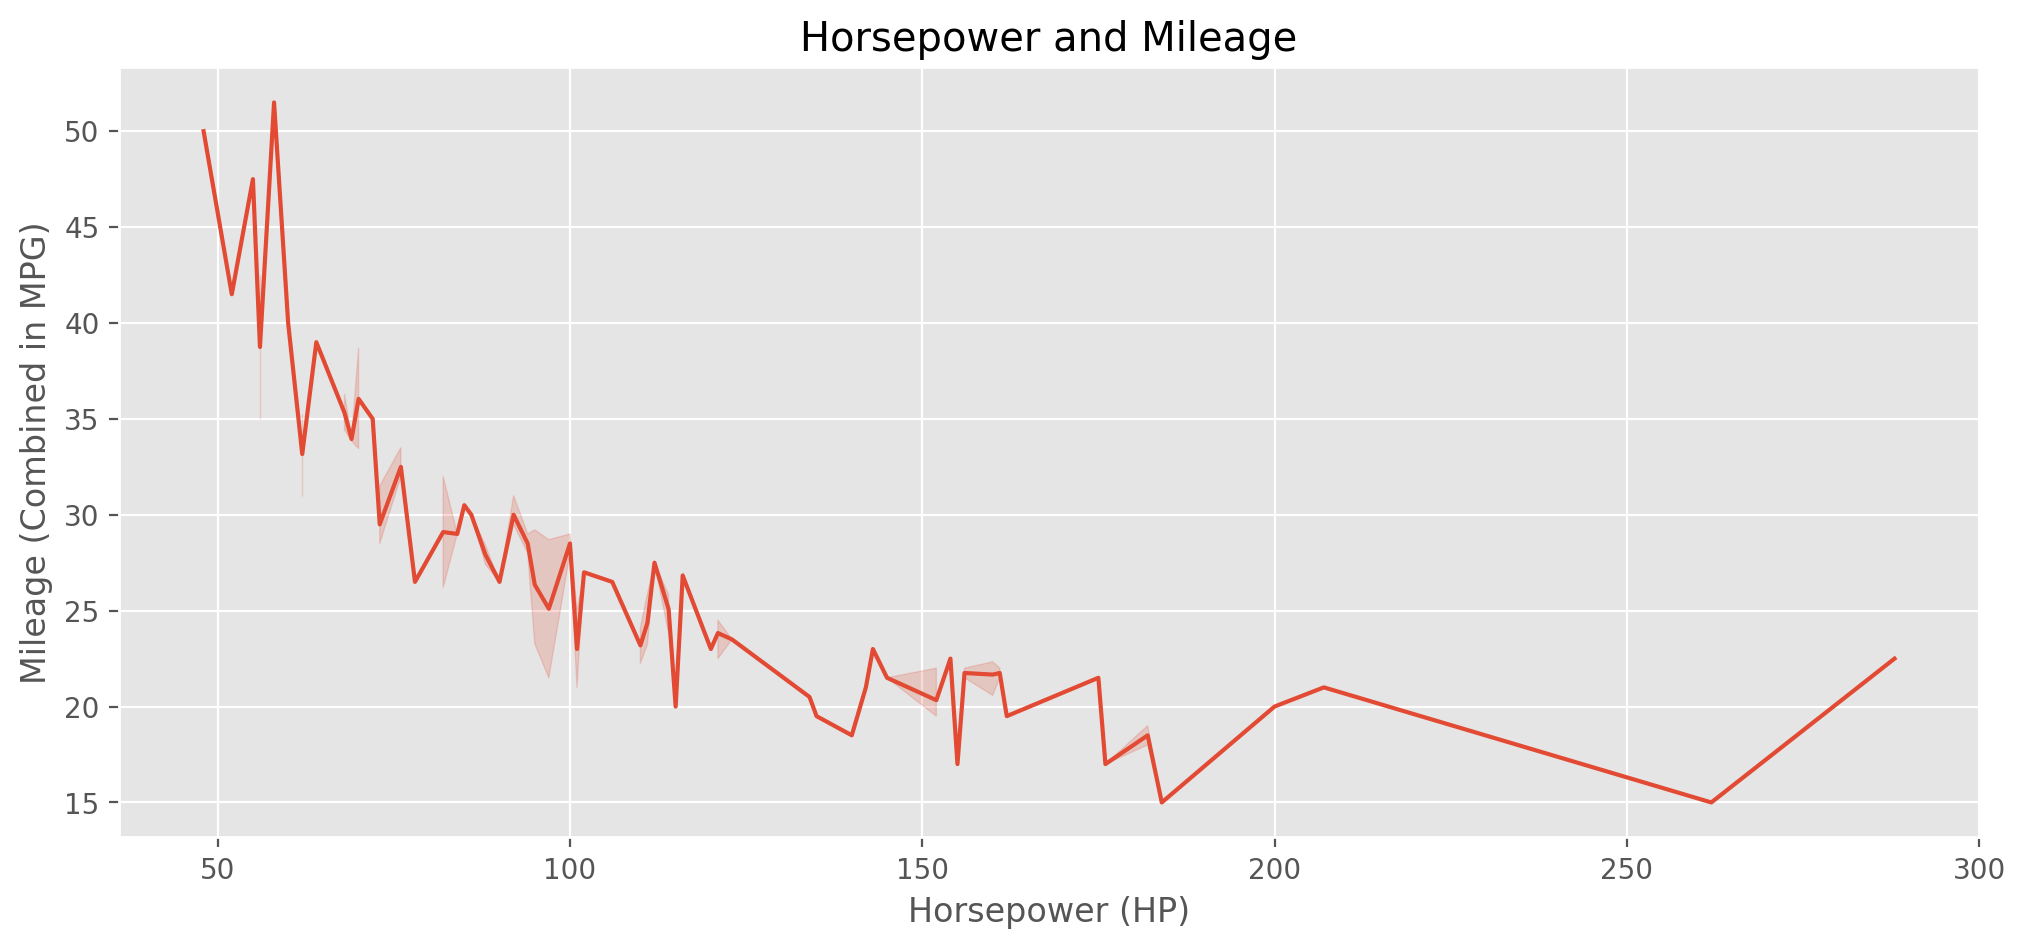

In [125]:
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(data = auto,x = 'horsepower', y= 'comb_mpg')

plt.title('Horsepower and Mileage')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Mileage (Combined in MPG)')

*  Observation: As the horsepower increases, the mileage also decreases.

* Pairplot over price of all categories.

<Figure size 640x480 with 0 Axes>

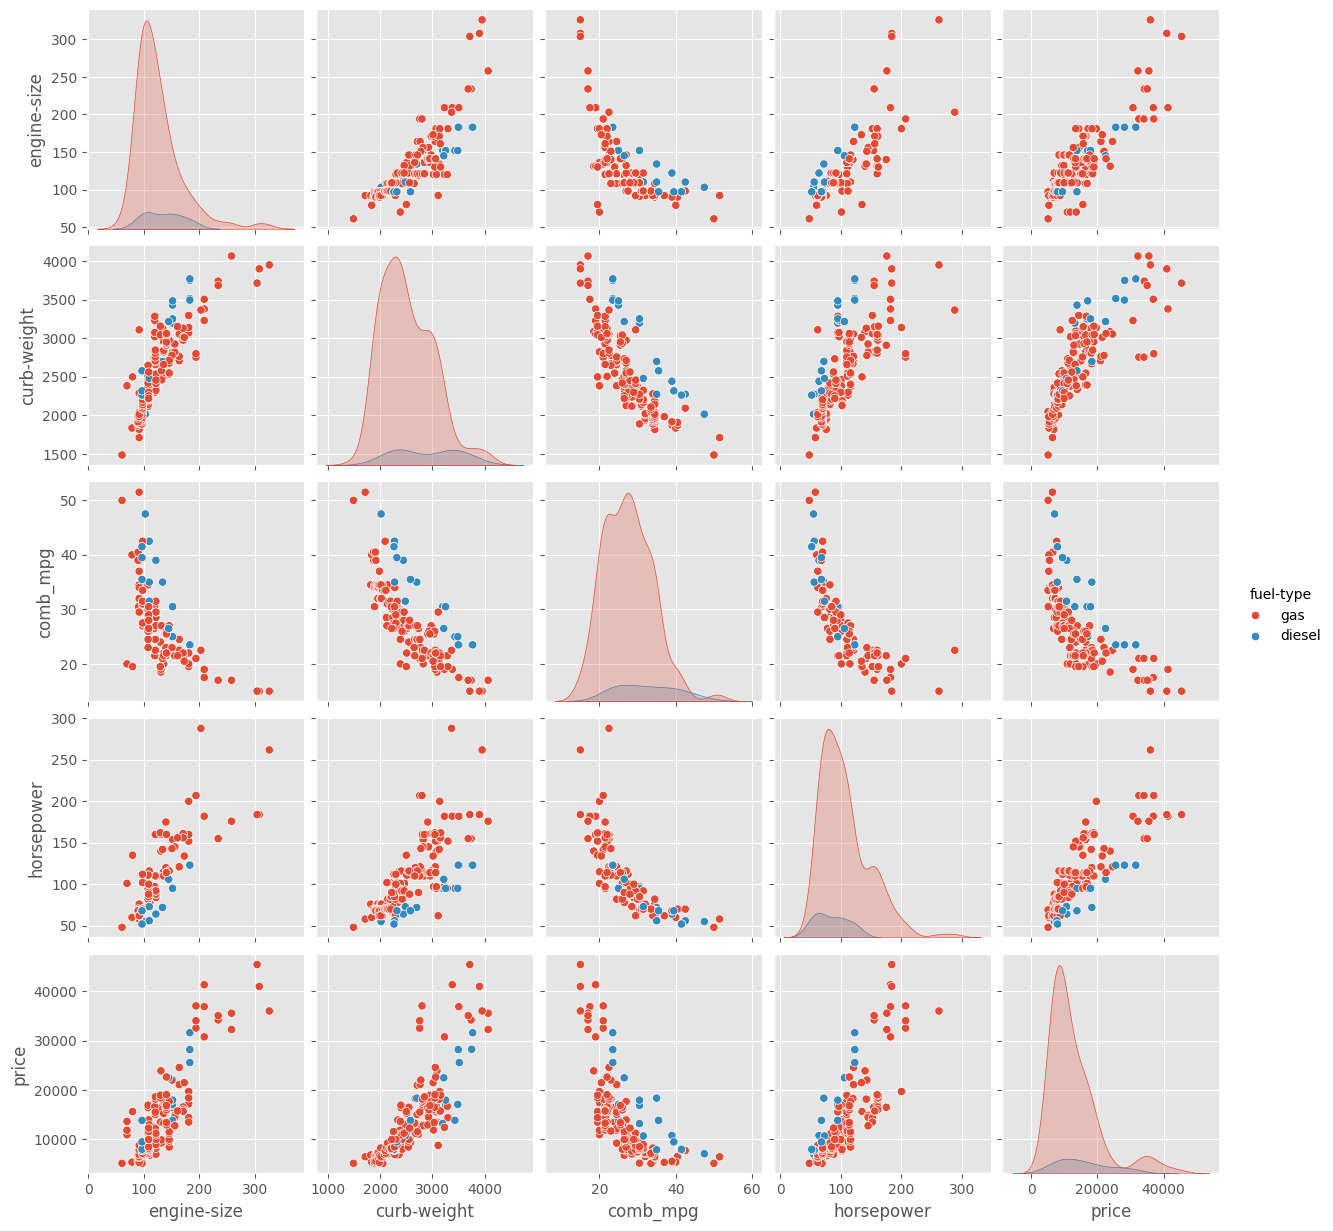

In [126]:
cols = ['engine-size', 'curb-weight', 'comb_mpg', 'horsepower', 'price', 'fuel-type']
plt.figure()
sns.pairplot(auto[cols], hue = 'fuel-type')
plt.savefig('pairplot', dpi = 1000)

* Detailed lineplot over mileage and horsepower.

<Axes: xlabel='horsepower', ylabel='comb_mpg'>

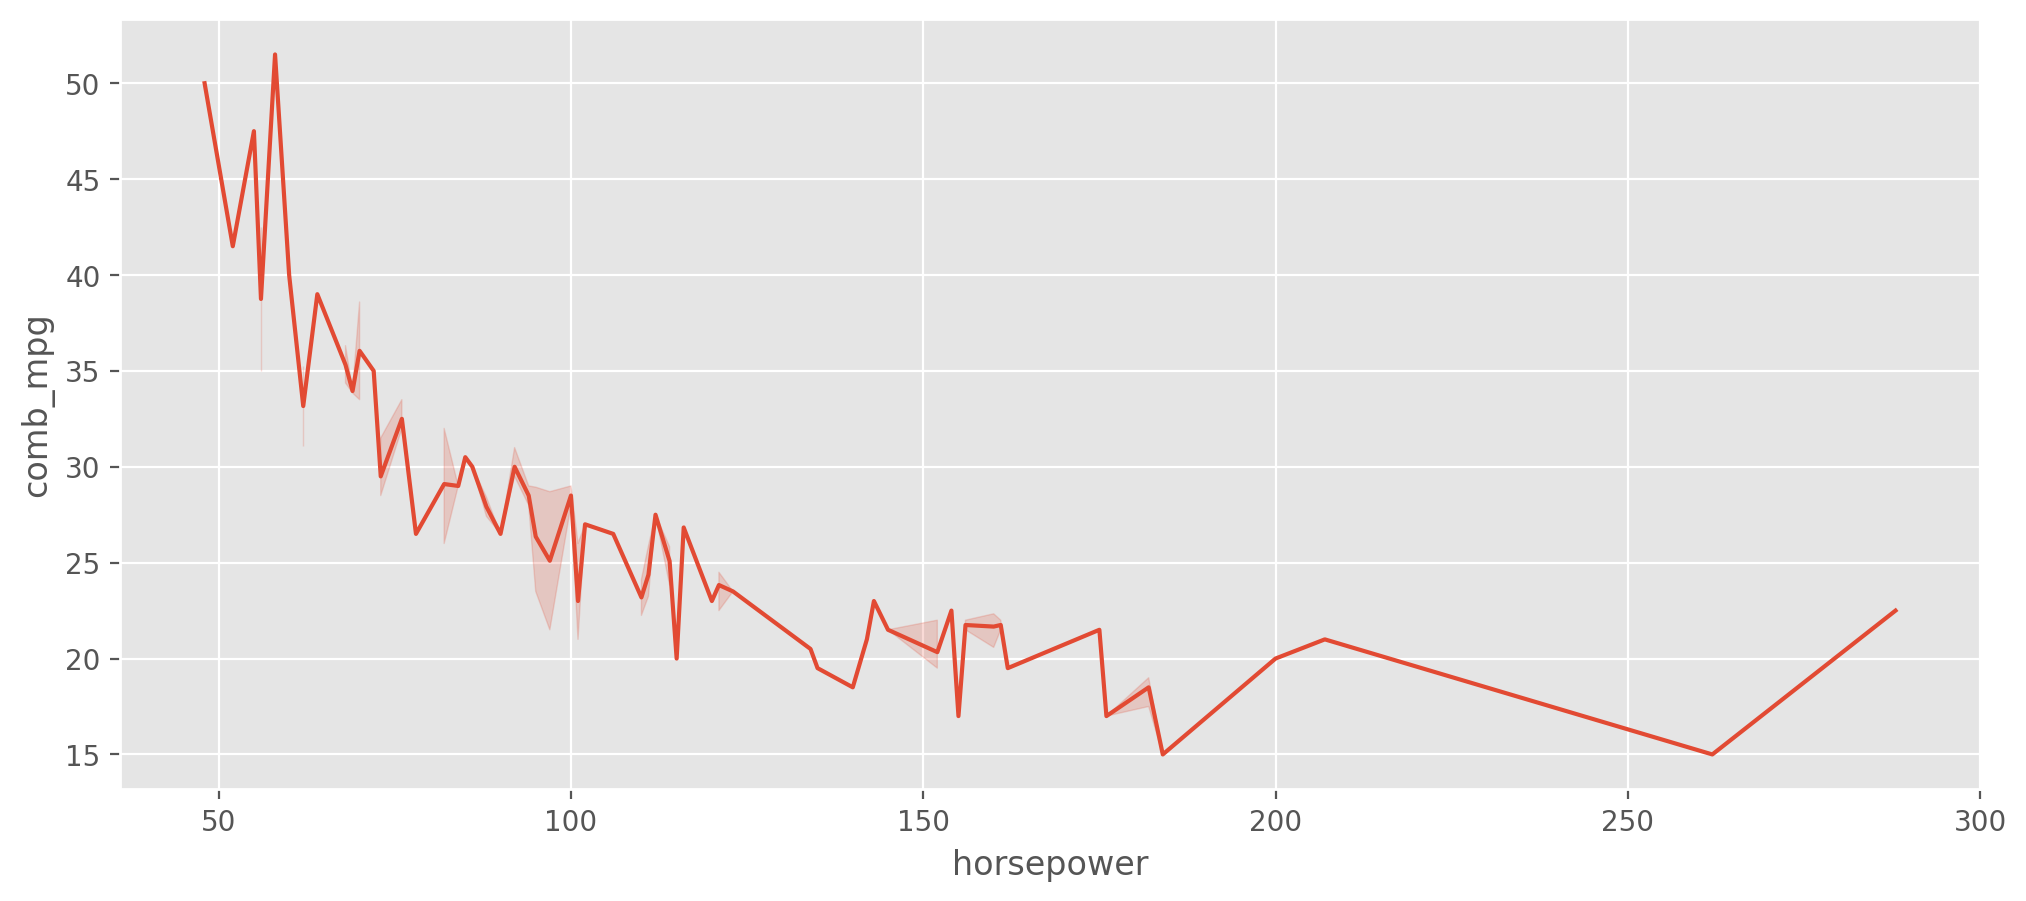

In [127]:
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(x = 'horsepower', y = 'comb_mpg', data = auto)

* Comparible lineplot over comb_mpg and curb_weight

<Axes: xlabel='curb-weight', ylabel='comb_mpg'>

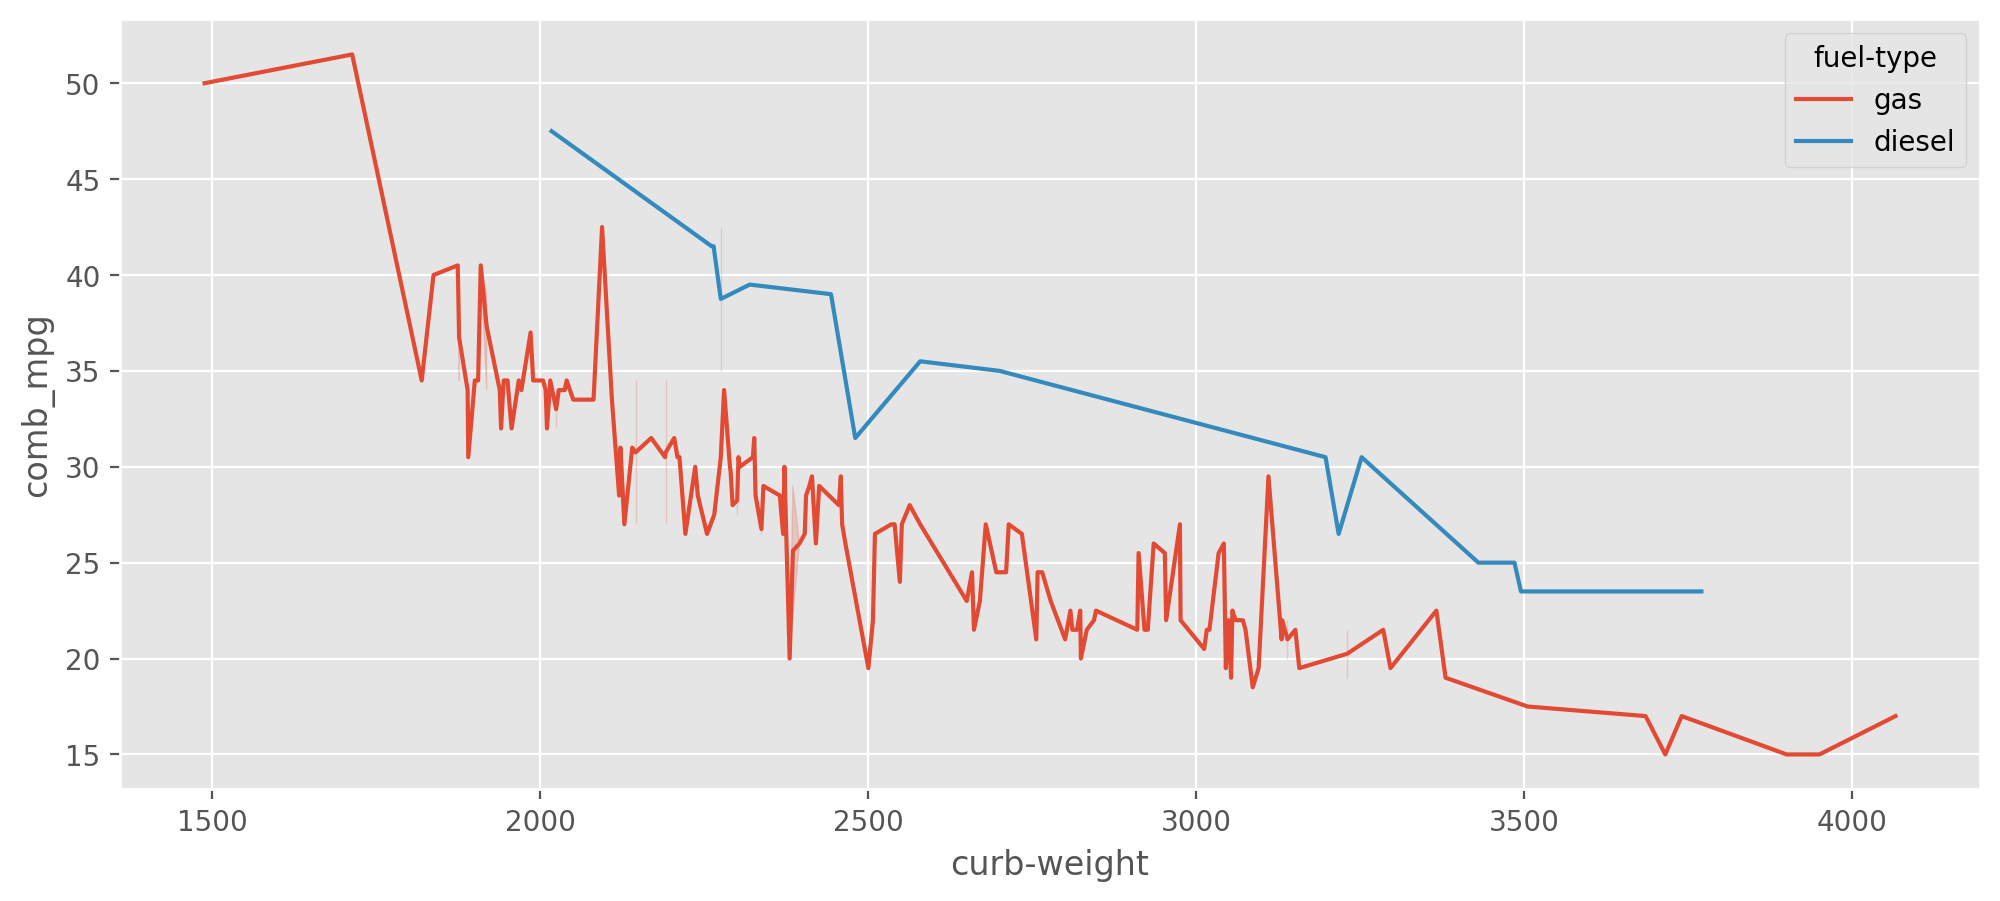

In [128]:
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(x='curb-weight', y = 'comb_mpg', data = auto, hue = 'fuel-type')

* Barplot over fuel-type and comb-mpg

<Axes: xlabel='fuel-type', ylabel='comb_mpg'>

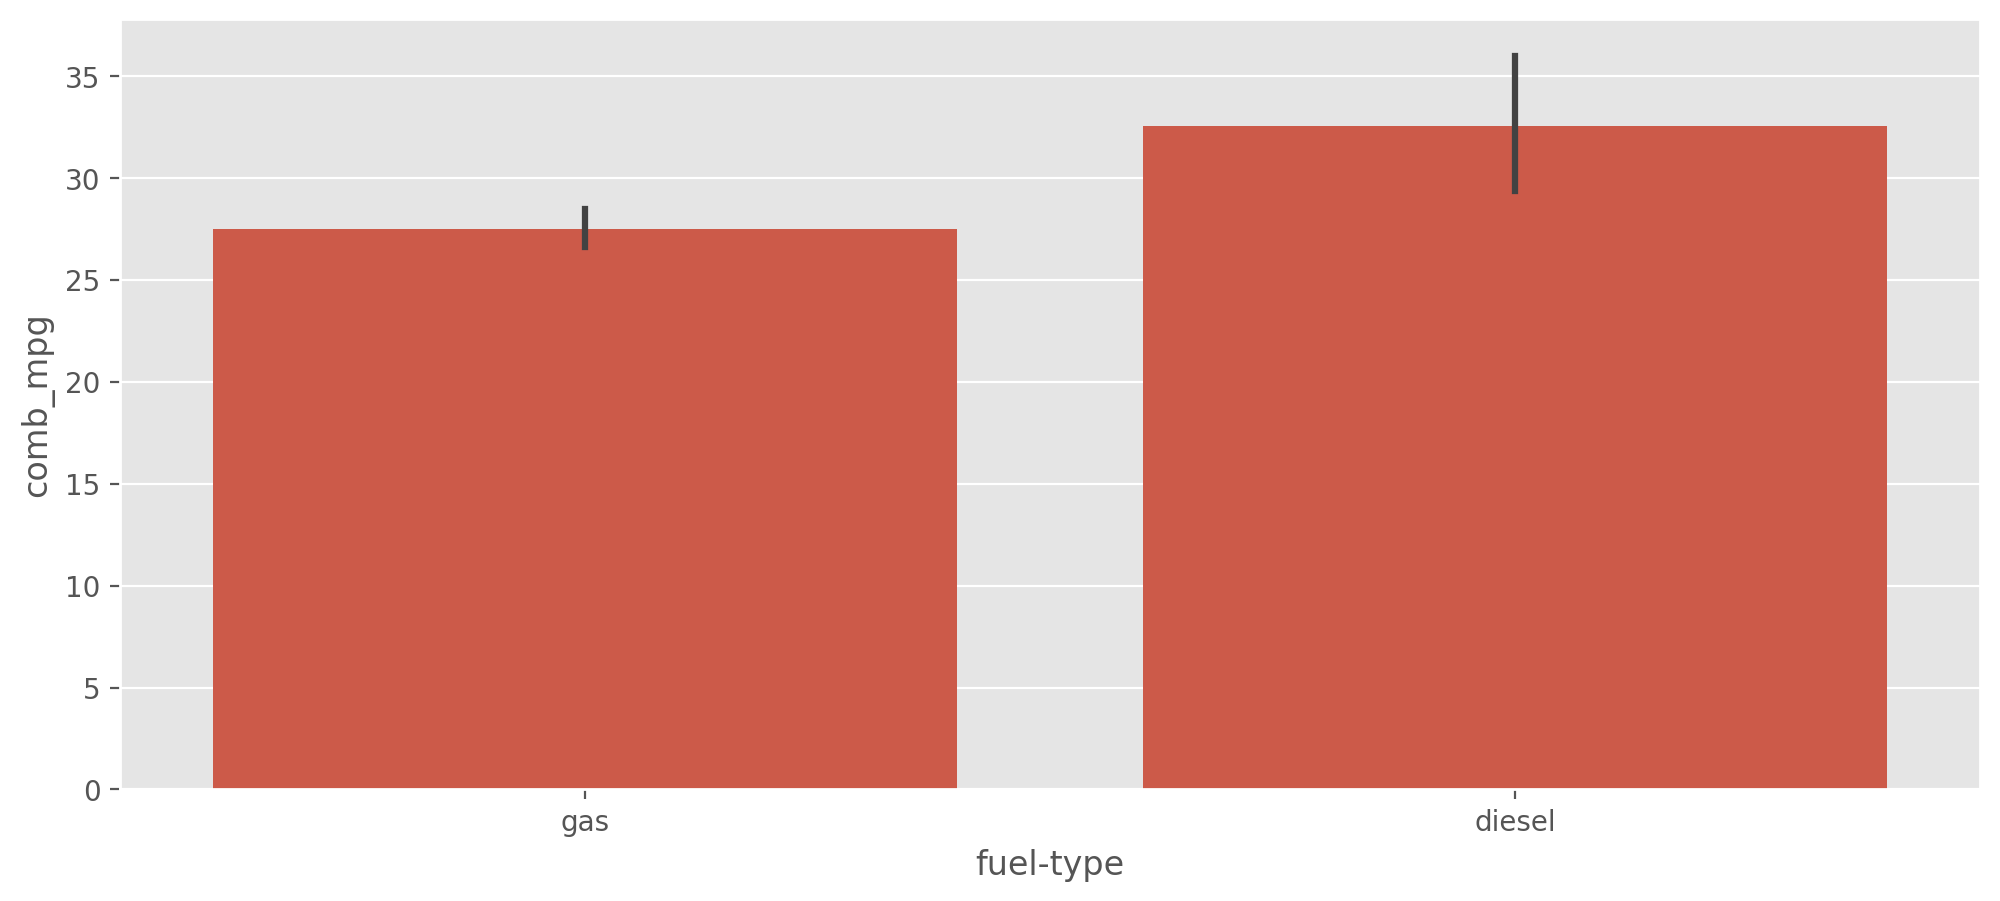

In [129]:
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x= 'fuel-type', y = 'comb_mpg', data = auto)

* Barplot over body-style and comb-mpg  

<Axes: xlabel='body-style', ylabel='comb_mpg'>

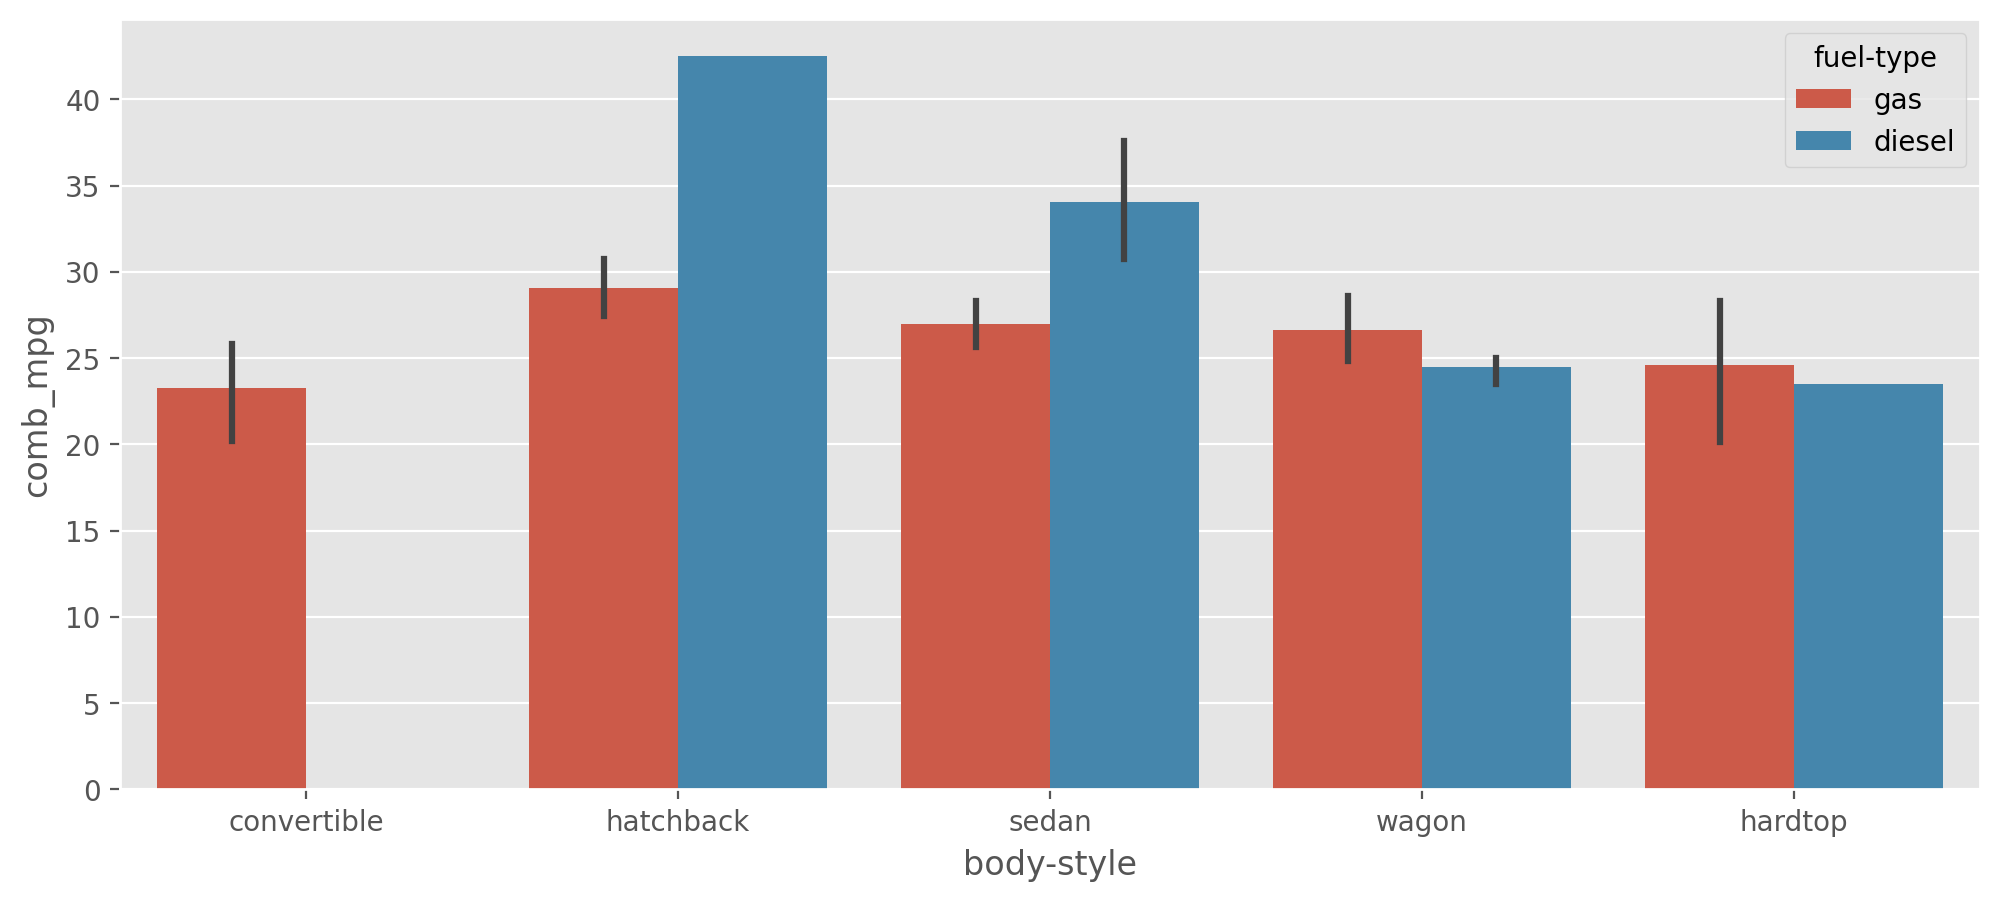

In [130]:
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x= 'body-style', y = 'comb_mpg', data = auto, hue = 'fuel-type')

* Barplot over body-style and price

<Axes: xlabel='price', ylabel='make'>

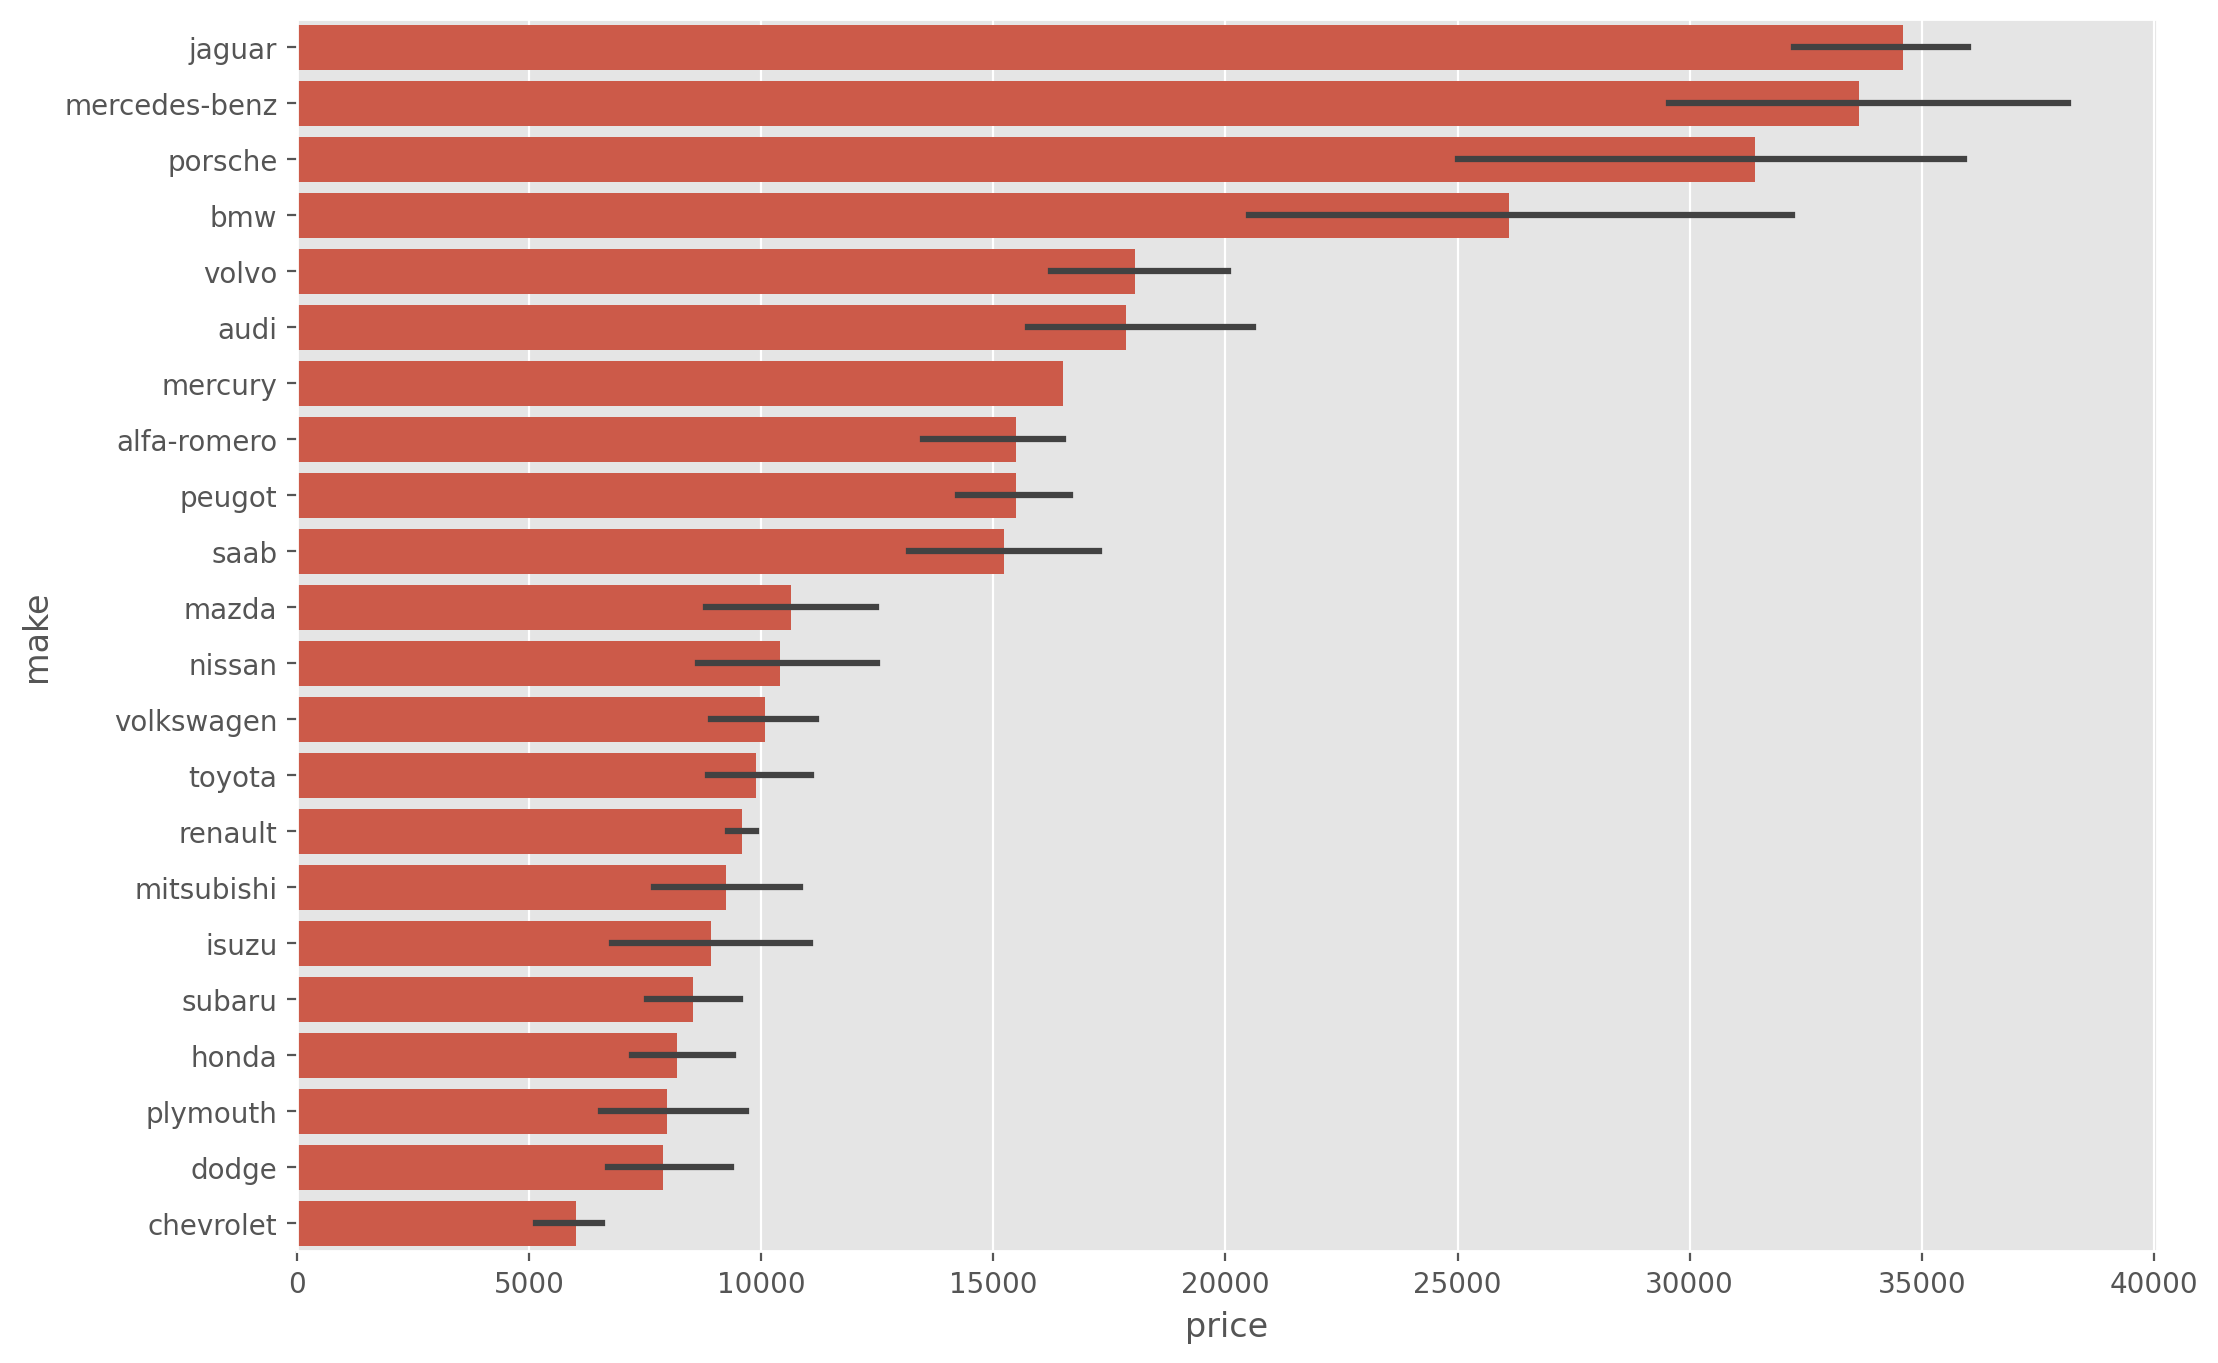

In [131]:
desc_order = auto.groupby('make')['price'].mean().sort_values(ascending = False).index
plt.figure(figsize = (12,8), dpi = 200)
sns.barplot(x = 'price', y = 'make', data = auto, order = desc_order)

* Count plot over count and fuel-type

<Axes: xlabel='fuel-type', ylabel='count'>

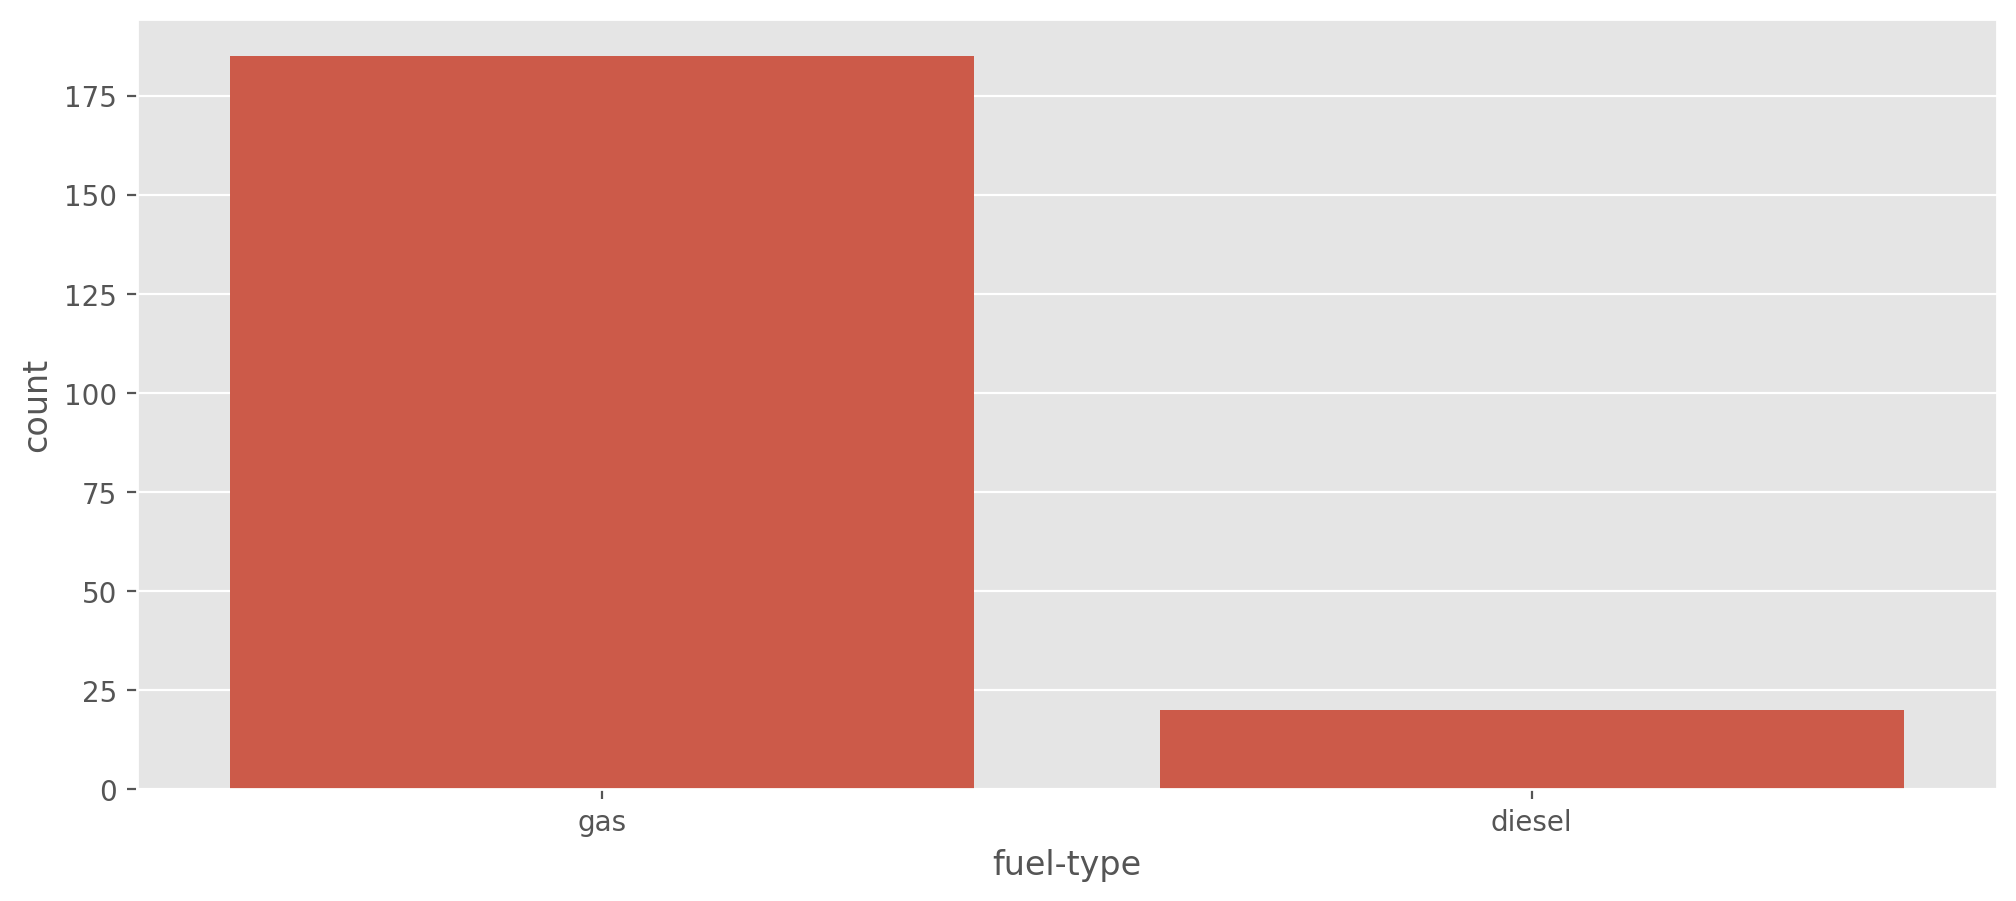

In [132]:
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot(x = 'fuel-type', data = auto)

## Outliers

* Boxplot over price of all categories.


<Axes: ylabel='price'>

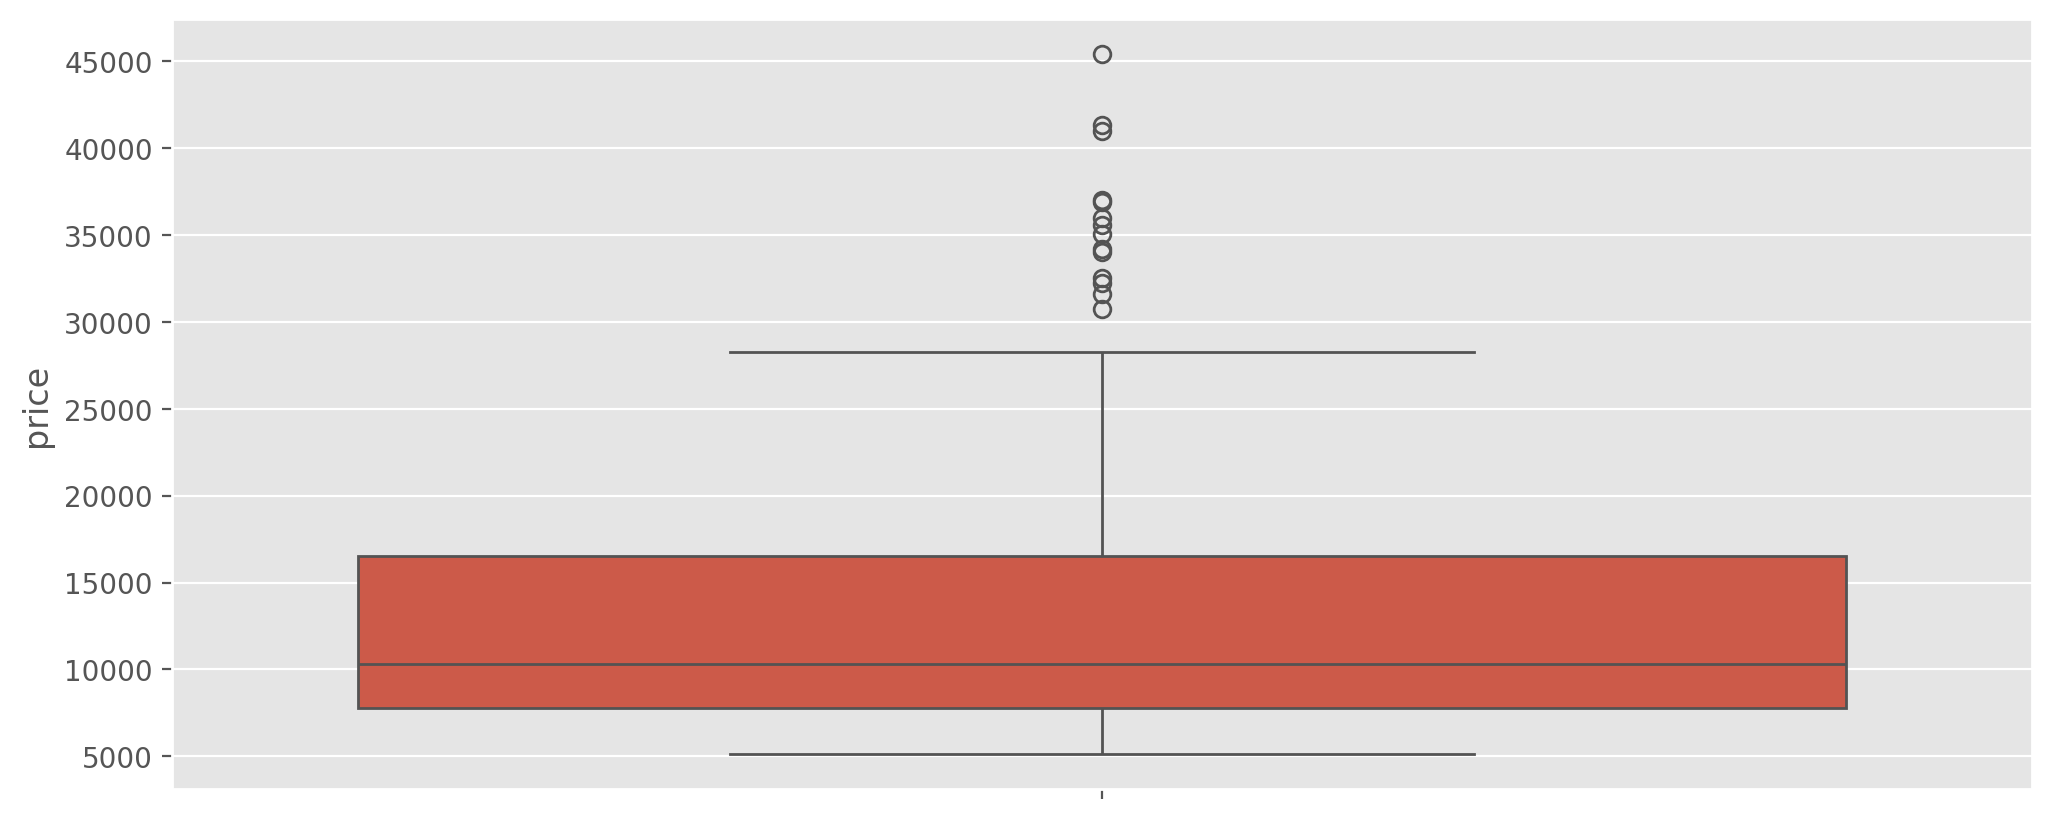

In [133]:
plt.figure(figsize = (12,5), dpi = 200)
sns.boxplot(y = 'price', data = auto)

* Heatmap over correlation of all columns.

<Axes: >

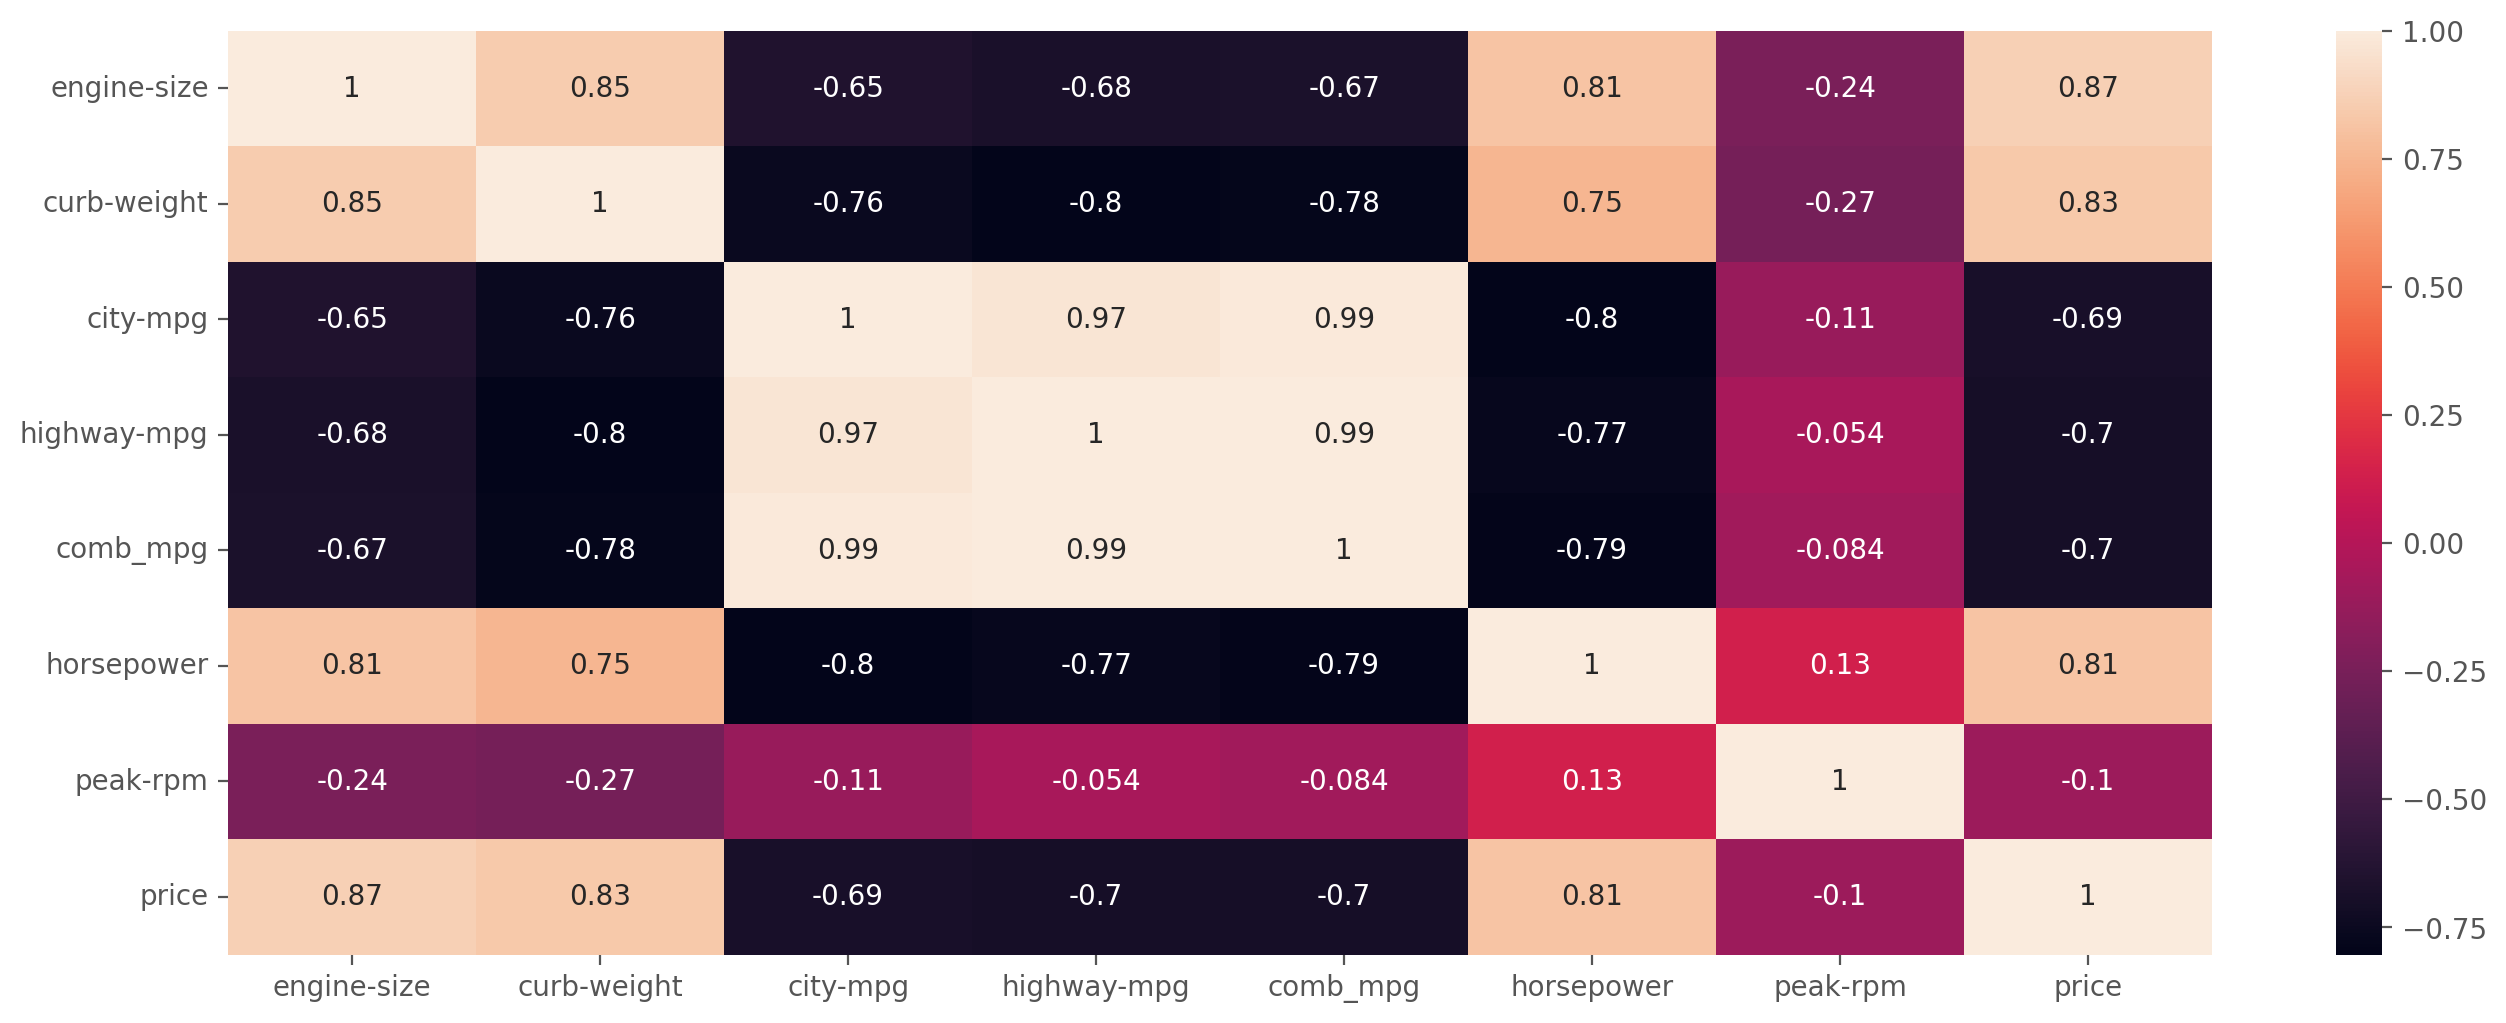

In [138]:
cols = ['engine-size', 'curb-weight', 'city-mpg', 'highway-mpg', 'comb_mpg', 'horsepower', 'peak-rpm', 'price']
plt.figure(figsize = (16,6), dpi = 200)
sns.heatmap(auto[cols].corr(), annot = True)

In [139]:
auto.to_csv("heart.csv")